<a href="https://colab.research.google.com/github/Pranjli-S/DS-Assignments-2026/blob/main/Assignment-02/Movie_Production_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primary Matrix Shape: (12, 12)
Unique Genre Sample: {np.str_('Action'): np.int64(42), np.str_('Comedy'): np.int64(29), np.str_('Drama'): np.int64(29)}
Advanced NumPy operations finalized.
------------------------------

Pandas Coordinate Slice:
   Project_ID     Studio
0        1001  Universal
1        1002     Warner
2        1003     Disney
------------------------------

Missing Values per Column:
id                          0
belongs_to_collection    2396
budget                      0
genres                      7
homepage                 2054
dtype: int64


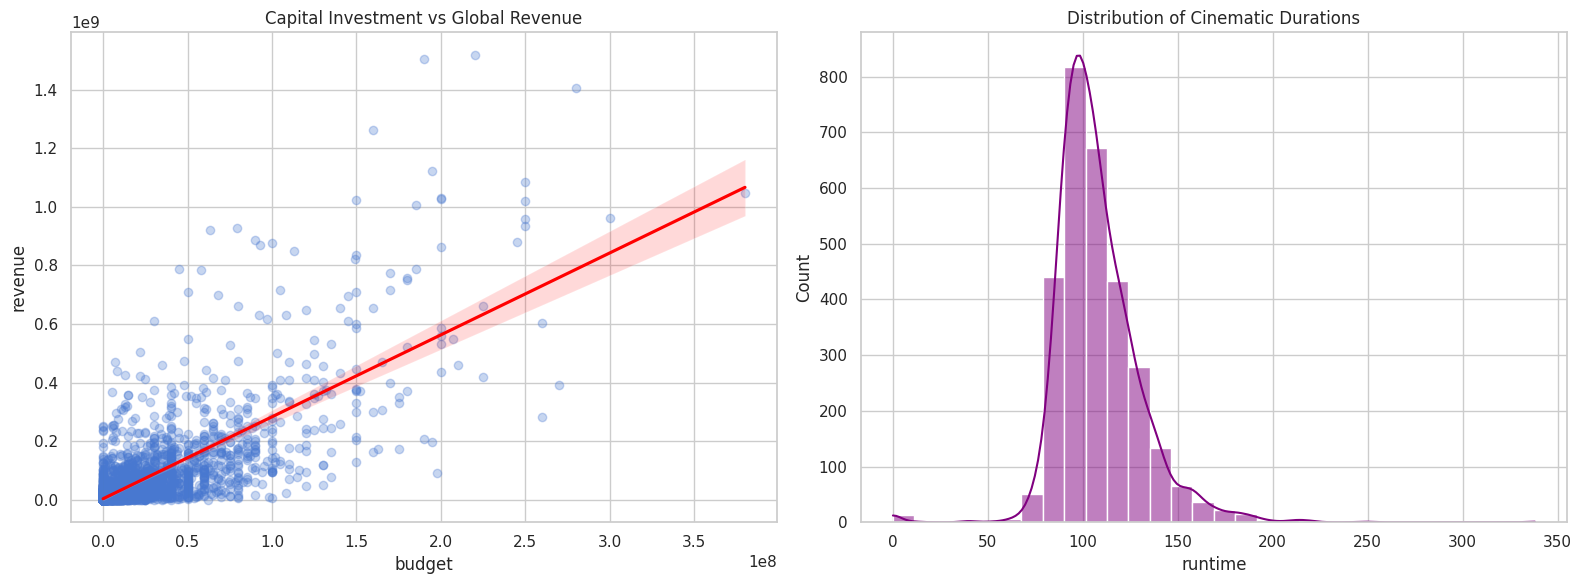

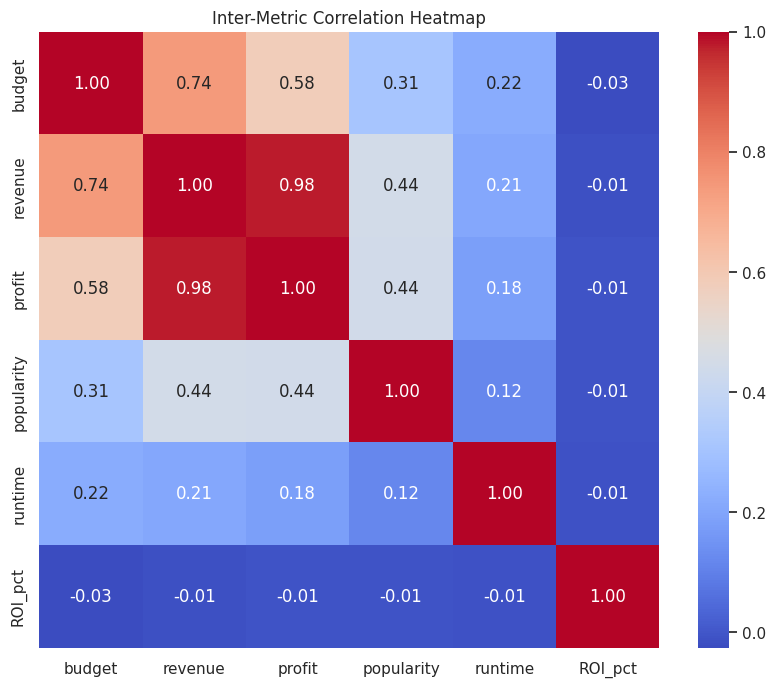

/tmp/ipykernel_12465/1748756981.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genre_names', y='profit', data=filtered_genres, palette="Set3")


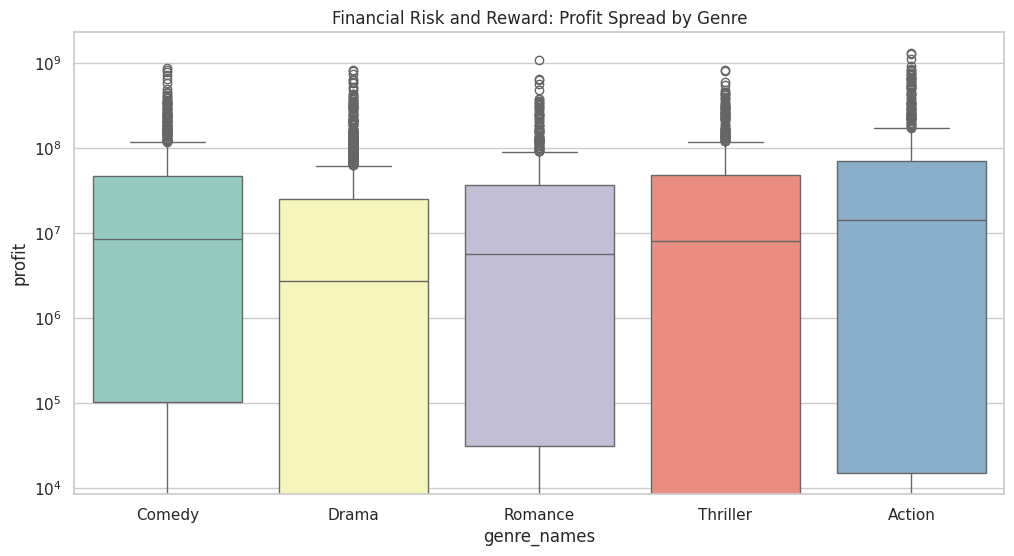

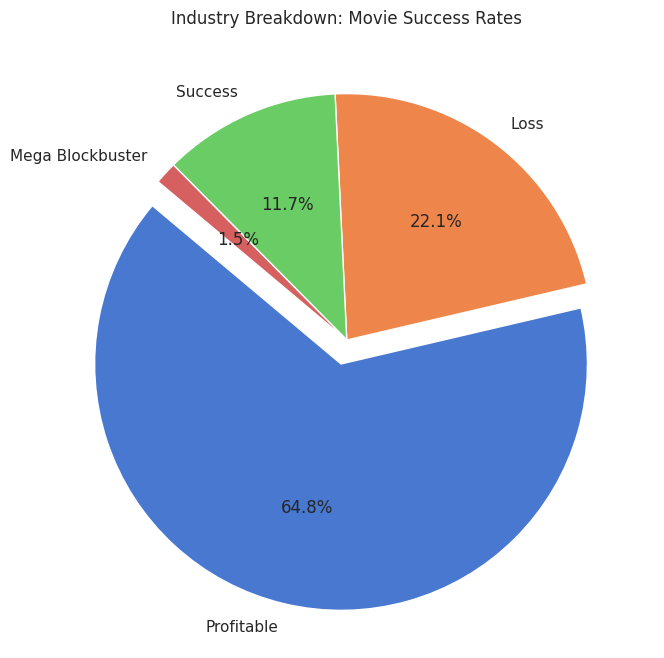


Assignment 02 Finalized. All analytics and visualizations rendered successfully.


In [5]:
# ==========================================
# 1. IMPORT CORE LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datetime import datetime, date, timedelta

# ==========================================
# 2. NUMPY: MATRIX & VECTOR OPERATIONS
# ==========================================
# Creating a series of multi-dimensional arrays for structural testing
matrix_large = np.array(np.random.randint(10, 100, (12, 12)))
print(f"Primary Matrix Shape: {matrix_large.shape}")

# np.transpose: Inverting the matrix for orientation analysis
matrix_t = np.transpose(matrix_large)

# np.reshape: Reorganizing data into a 3D Tensor (4 blocks of 6x6)
tensor_3d = np.reshape(matrix_large, (4, 6, 6))

# np.flatten & np.resize: Handling memory layouts
flat_view = matrix_large.flatten()
resized_view = np.resize(matrix_large, (15, 10)) # Expanding dimensions

# np.insert, np.append, np.delete: Dynamic array editing
arr_edit = np.array([10, 20, 30, 40])
arr_edit = np.insert(arr_edit, 2, 99)
arr_edit = np.append(arr_edit, [50, 60])
arr_edit = np.delete(arr_edit, 0)

# np.unique: Identifying distinct value sets and frequencies
data_stream = np.random.choice(['Action', 'Drama', 'Comedy'], size=100)
genres, counts = np.unique(data_stream, return_counts=True)
print(f"Unique Genre Sample: {dict(zip(genres, counts))}")

# Broadcasting & Element-wise Math: Simulating weight adjustments
weights = np.random.rand(4)
features = np.random.randint(1, 10, (10, 4))
weighted_features = features * weights # Broadcasting happens here
div_res = np.divide(features, 2.5)
mult_res = np.multiply(features, 1.1)

print("Advanced NumPy operations finalized.")
print("-" * 30 + "\n")

# ==========================================
# 3. PANDAS: ADVANCED DATA WRANGLING
# ==========================================
# Diagnostic DataFrame creation for syntax validation
demo_data = {
    'Project_ID': np.arange(1001, 1006),
    'Studio': ['Universal', 'Warner', 'Disney', 'Paramount', 'Netflix'],
    'Budget_M': [150, 200, 250, 180, 160],
    'Score': [7.8, 8.2, 9.0, 6.5, 7.1]
}
demo_df = pd.DataFrame(demo_data)

# iloc & Indexing: Slicing specific data coordinates
# Selecting the first 3 rows and first 2 columns
coordinate_slice = demo_df.iloc[0:3, 0:2]

# Column Manipulation: Complex Logic
demo_df['Status'] = np.where(demo_df['Score'] > 8.0, 'Must Watch', 'Average')
demo_df['Budget_After_Tax'] = demo_df['Budget_M'].apply(lambda x: x * 0.85)

# Dropping redundant columns
demo_df = demo_df.drop(columns=['Project_ID'])

print(f"Pandas Coordinate Slice:\n{coordinate_slice}")
print("-" * 30 + "\n")

# ==========================================
# 4. IMDB PROJECT: DATA CLEANING & ENGINEERING
# ==========================================
# Load main dataset
movie_df = pd.read_csv('imdb_data.csv')

# Pre-Cleaning Diagnostic
print(f"Missing Values per Column:\n{movie_df.isnull().sum().head(5)}")

# Robust JSON Parsing Function
def parse_json_column(data):
    if pd.isna(data) or data == "": return []
    return ast.literal_eval(data)

# Transforming string-based lists into Python objects
movie_df['genres_list'] = movie_df['genres'].apply(parse_json_column)
movie_df['cast_list'] = movie_df['cast'].apply(parse_json_column)

# Extracting critical names for analysis
movie_df['genre_names'] = movie_df['genres_list'].apply(lambda x: [i['name'] for i in x])
movie_df['top_actor'] = movie_df['cast_list'].apply(lambda x: x[0]['name'] if len(x) > 0 else "Unknown")

# Financial Calculations with Error Handling
movie_df['profit'] = movie_df['revenue'] - movie_df['budget']
movie_df['ROI_pct'] = (movie_df['profit'] / movie_df['budget'].replace(0, np.nan)) * 100

# Mapping Profit Categories
def categorize_profit(p):
    if p > 500000000: return 'Mega Blockbuster'
    if p > 100000000: return 'Success'
    if p > 0: return 'Profitable'
    return 'Loss'

movie_df['Performance_Category'] = movie_df['profit'].apply(categorize_profit)

# ==========================================
# 5. INTEGRATED DATA VISUALIZATION
# ==========================================
sns.set_theme(style="whitegrid", palette="muted")

# --- GRID VISUALIZATION 1: Multi-Plot Insight ---
# Showing Revenue vs Budget and Runtime Distribution side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatterplot with Regression Line
sns.regplot(x='budget', y='revenue', data=movie_df, ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title("Capital Investment vs Global Revenue")

# Histogram of Runtimes
sns.histplot(movie_df['runtime'].dropna(), bins=30, kde=True, ax=axes[1], color='purple')
axes[1].set_title("Distribution of Cinematic Durations")

plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: Correlation Heatmap ---
plt.figure(figsize=(10, 8))
numeric_cols = movie_df[['budget', 'revenue', 'profit', 'popularity', 'runtime', 'ROI_pct']].dropna()
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Inter-Metric Correlation Heatmap")
plt.show()

# --- VISUALIZATION 3: Box Plot of Profit by Genre ---
# Exploding the genre list to analyze each genre individually
exploded_df = movie_df.explode('genre_names')
top_5_genres = exploded_df['genre_names'].value_counts().head(5).index
filtered_genres = exploded_df[exploded_genres['genre_names'].isin(top_5_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='genre_names', y='profit', data=filtered_genres, palette="Set3")
plt.yscale('log')




plt.title("Financial Risk and Reward: Profit Spread by Genre")
plt.show()

# --- VISUALIZATION 4: Performance Categories Pie Chart ---
plt.figure(figsize=(8, 8))
performance_counts = movie_df['Performance_Category'].value_counts()
plt.pie(performance_counts, labels=performance_counts.index, autopct='%1.1f%%', startangle=140, explode=[0.1, 0, 0, 0])
plt.title("Industry Breakdown: Movie Success Rates")
plt.show()

print("\nAssignment 02 Finalized. All analytics and visualizations rendered successfully.")